# Books API Data Exploration 

### Imports and API Set Up

In [2]:
import requests 
import pandas as pd 
import os 
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [3]:
load_dotenv()
API_KEY = os.getenv('GOOGLE_BOOKS_API_KEY')

### Get Sample of Books

In [19]:
def sample_book_data(genre, max_results=10):
    """get a sample of books from google books api by genre"""
    url = "https://www.googleapis.com/books/v1/volumes"
    books = []

    params = {"q": f"subject:{genre}",
             "key": API_KEY, 
             "maxResults": max_results,
             "printType": "books",
             "langRestrict": "en"}

    response = requests.get(url, params = params)
    data = response.json()

    for book in data.get("items", []):
        info = book.get("volumeInfo", {})
        #print(info)
        book = {
            "title": info.get("title", "Unknown"),
            "authors": ", ".join(info.get("authors", ["Unknown"])),
            "publisher": info.get("publisher", "Unknown"),
            "subject": genre,
            "categories": ", ".join(info.get("categories", ["Unknown"])),
            "maturityRating": info.get("maturityRating", "Unknown"),
            "page_count": info.get("pageCount", 0),
            "average_rating": info.get("averageRating", 0),
            "ratings_count": info.get("ratingsCount", 0),
            "published_date": info.get("publishedDate", "Unknown"),
            "description": info.get("description", "")
        }
        books.append(book)

    return books

In [20]:
#get small sample across genres 
genres = ["fiction", "romance", "fanstasy", "historical fiction", "biography", "nonfiction", "mystery", "thriller"]
all_books = []

for genre in genres: 
    all_books.extend(sample_book_data(genre))

df = pd.DataFrame(all_books)
print(f"total books sampled:{len(df)}")
df.head()

total books sampled:73


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ..."
1,The Natural,Bernard Malamud,Macmillan,fiction,Fiction,NOT_MATURE,250,0.0,0,1952,Story of a baseball player's record-shattering...
2,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...
3,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...
4,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...


#### Look at df 

In [21]:
#shape and columns of df 
print("shape: ", df.shape)
print("\ncolumns: ", df.columns.tolist())
print("\ndatatype: ", df.dtypes)

shape:  (73, 11)

columns:  ['title', 'authors', 'publisher', 'subject', 'categories', 'maturityRating', 'page_count', 'average_rating', 'ratings_count', 'published_date', 'description']

datatype:  title                 str
authors               str
publisher             str
subject               str
categories            str
maturityRating        str
page_count          int64
average_rating    float64
ratings_count       int64
published_date        str
description           str
dtype: object


In [22]:
#check for nulls 
print("missing values over columns: ")
print(df.isnull().sum())

#check for 0 values
print("\n0 values: ")
print((df[["page_count", "average_rating", "ratings_count"]] == 0).sum())

missing values over columns: 
title             0
authors           0
publisher         0
subject           0
categories        0
maturityRating    0
page_count        0
average_rating    0
ratings_count     0
published_date    0
description       0
dtype: int64

0 values: 
page_count         5
average_rating    49
ratings_count     49
dtype: int64


In [23]:
df[["page_count", "average_rating", "ratings_count"]].describe()


,page_count,average_rating,ratings_count
count,73.000000,73.000000,73.000000
mean,364.205479,1.335616,3.794521
std,194.690849,1.956213,17.440342
min,0.000000,0.000000,0.000000
25%,260.000000,0.000000,0.000000
50%,356.000000,0.000000,0.000000
75%,455.000000,3.500000,2.000000
max,1061.000000,5.000000,147.000000


Page Count Distributions

In [25]:
df[df["page_count"] == 0]

,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
19,Heir of Fire,Sarah J. Maas,Turtleback Books,romance,Unknown,NOT_MATURE,0,0.0,0,2015-09,Celaena Sardothien rises from the ashes to bur...
23,The Blood of Flowers,Anita Amirrezvani,Unknown,historical fiction,American fiction,NOT_MATURE,0,5.0,1,2007,A dazzling debut novel about a young woman in ...
29,Shout at the Devil,Wilbur Smith,Zaffre Publishing,historical fiction,Adventure stories,NOT_MATURE,0,0.0,0,2018-06,An thrilling World War One adventure novel fro...
31,Aloha Love,Yvonne Lehman,Unknown,historical fiction,Hawai,NOT_MATURE,0,0.0,0,2012,"On a trip to Hawaii in 1899, Jane Buckley meet..."
32,The Story Spinner,Barbara Erskine,HarperCollins,historical fiction,Fiction,NOT_MATURE,0,0.0,0,2024-07-31,From the Sunday Times bestselling author of La...


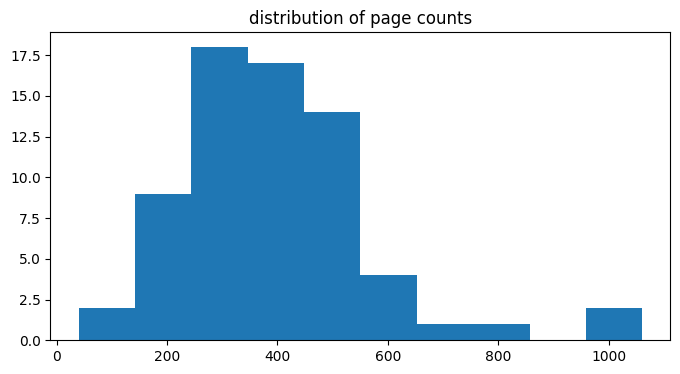

In [31]:
#remove 0 page counts
df_clean = df[df["page_count"] > 0]

plt.figure(figsize=(8, 4))
plt.hist(df_clean["page_count"], bins=10)
plt.title("distribution of page counts")
plt.show()

Ratings

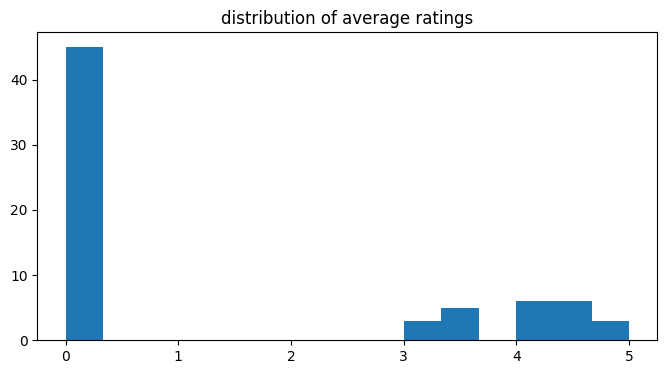

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean["average_rating"], bins=15)
plt.title("distribution of average ratings")
plt.show()

Genres

In [43]:
#determined by the genres given to API to pull 
genre_counts = df["subject"].value_counts()
genre_counts

subject
fiction               10
romance               10
historical fiction    10
biography             10
nonfiction            10
mystery               10
thriller              10
fanstasy               3
Name: count, dtype: int64

Categories

In [41]:
#one layer down from genre 
category_counts = df["categories"].value_counts()
category_counts

categories
Fiction                      42
Biography & Autobiography     8
Juvenile Fiction              3
Biography                     2
Business & Economics          2
Literary Criticism            1
American poetry               1
Unknown                       1
Fantasy.                      1
Fanstasy                      1
American fiction              1
Adventure stories             1
Hawai                         1
Political Science             1
Art                           1
History                       1
Body, Mind & Spirit           1
Family & Relationships        1
Medical                       1
Cooking                       1
Education                     1
Name: count, dtype: int64

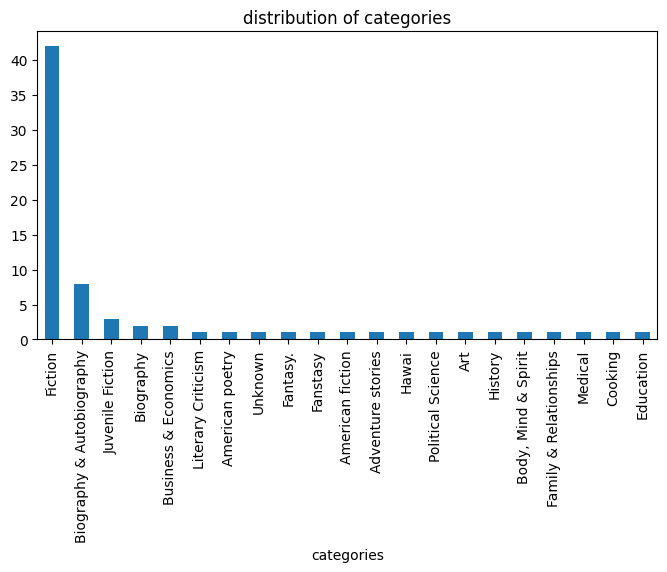

In [42]:
plt.figure(figsize=(8, 4))
category_counts.plot(kind="bar")
plt.title("distribution of categories")
plt.show()

Publish Date

In [44]:
df[df["published_date"] == "Unknown"]

,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description


In [46]:
df["published_date"].head(5)

0    2012-06-05
1          1952
2    2006-04-25
3    2001-01-01
4    1998-09-08
Name: published_date, dtype: str

In [47]:
def normalize_date(date_str):
    """normalize the dates """
    #empty or unknown date -- NaT 
    if pd.isna(date_str) or date_str == "Unknown":
        return pd.NaT
    #if the date is just a year, add -01-01 to make it a full date
    if len(str(date_str).strip()) == 4:
        return pd.to_datetime(str(date_str) + "-01-01", errors='coerce')
    return pd.to_datetime(date_str, errors='coerce')


In [48]:
df["published_date"] = df["published_date"].apply(normalize_date)

In [49]:
print(df["published_date"].head(5))

0   2012-06-05
1   1952-01-01
2   2006-04-25
3   2001-01-01
4   1998-09-08
Name: published_date, dtype: datetime64[us]


In [57]:
df[df["published_date"].isnull()]

,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description


In [58]:
df["published_date"].describe()

count                            73
mean     1998-10-11 15:27:07.397260
min             1841-01-01 00:00:00
25%             1998-01-01 00:00:00
50%             2005-08-23 00:00:00
75%             2014-10-14 00:00:00
max             2024-07-31 00:00:00
Name: published_date, dtype: object

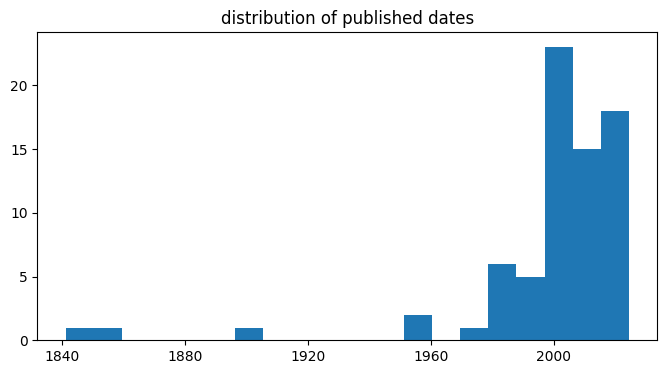

In [54]:
plt.figure(figsize = (8, 4))
plt.hist(df["published_date"], bins=20)
plt.title("distribution of published dates")
plt.show()